# Фундаментальный анализ пайплайна
## Data Fusion 2026 "Страж" — Fraud Detection

Цель: разобрать ВСЁ с нуля — валидация, метки, фичи, метрики, визуализации.

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import average_precision_score, precision_recall_curve
from pathlib import Path
from datetime import datetime
import warnings, gc, json
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True

ROOT = Path('/home/vadim/PyPr/hak')
DATA = ROOT / 'main_data'
FEATURES = ROOT / 'features'

print("Загрузка...")

# Метки
labels = pl.read_parquet(DATA / 'train_labels.parquet')
fraud_ids = set(labels.filter(pl.col('target') == 1)['event_id'].to_list())
confirmed_ids = set(labels.filter(pl.col('target') == 0)['event_id'].to_list())
all_label_ids = fraud_ids | confirmed_ids

print(f"Метки: {len(labels):,} всего")
print(f"  Fraud (red):     {len(fraud_ids):,}")
print(f"  Confirmed (yellow): {len(confirmed_ids):,}")
print(f"  Ratio fraud/confirmed: {len(fraud_ids)/len(confirmed_ids):.2f}")

# Валидация
val_ids = set(pl.read_parquet(FEATURES / 'val_event_ids.parquet')['event_id'].to_list())
print(f"\nVal set: {len(val_ids):,} event_ids")

# Train assembled
train_full = pl.read_parquet(FEATURES / 'train_features_full.parquet')
print(f"Train assembled: {len(train_full):,} строк")

# Val proper
val_df = pl.read_parquet(FEATURES / 'val_proper.parquet')
print(f"Val proper: {len(val_df):,} строк")

# Test
test_df = pl.read_parquet(FEATURES / 'test_features.parquet')
test_df = test_df.unique(subset=['event_id'], keep='first')
print(f"Test: {len(test_df):,} строк")

print("\nГотово!")

Загрузка...
Метки: 87,514 всего
  Fraud (red):     51,438
  Confirmed (yellow): 36,076
  Ratio fraud/confirmed: 1.43

Val set: 523,280 event_ids
Train assembled: 2,659,398 строк
Val proper: 523,280 строк


Test: 633,683 строк

Готово!


---
## 1.1 Логика разбиения (Validation Strategy)

**Как устроен тест:**
- 70 дней: 2025-06-01 → 2025-08-09 (10 недель)
- Для каждого клиента — один случайный день из этого периода (633K операций)
- Public LB (30%) = недели 1, 3, 5 | Private LB (70%) = остальные 7

**Как устроен наш val:**
- Из полных 85M строк train (Oct'24 — May'25) для каждого клиента выбран один случайный день
- Val = 523K операций, 430 fraud (0.082%)
- Имитирует структуру теста, но из ДРУГОГО временного периода

**Вопросы для проверки:**
1. Есть ли gap между train и val?
2. Какое распределение дат в val?
3. Совпадают ли клиенты между train/val/test?

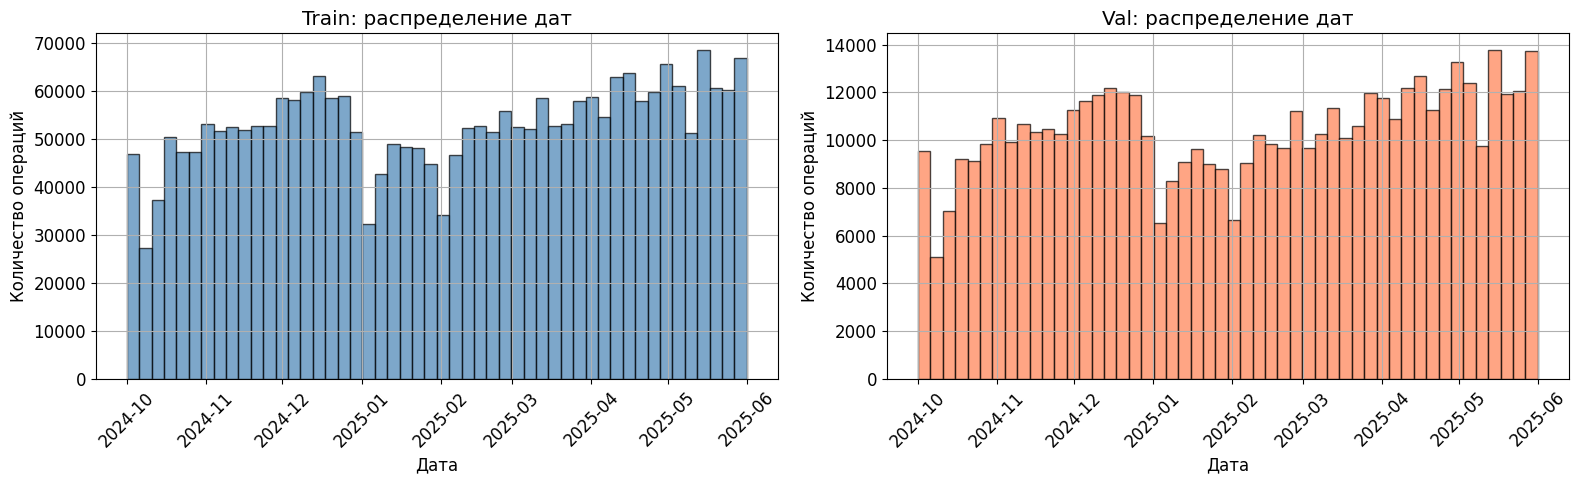

ВРЕМЕННЫЕ ДИАПАЗОНЫ
Train assembled: 2024-10-01 00:00:05 → 2025-05-31 23:59:54
Val proper:      2024-10-01 00:00:47 → 2025-05-31 23:57:22
Test:            2025-06-01 00:00:13 → 2025-08-09 23:58:25

Gap train→val: НЕТ (val выбирается из train периода)
Gap train→test: 0 дней

ПЕРЕСЕЧЕНИЕ КЛИЕНТОВ
Train клиентов: 99,952
Val клиентов:   100,000
Test клиентов:  94,241
Train ∩ Val:    99,952 (100.0%)
Train ∩ Test:   94,207 (100.0%)
Val ∩ Test:     94,241 (100.0%)

Val fraud dates:     2024-10-03 15:36:03 → 2025-05-30 22:48:57
Val non-fraud dates: 2024-10-01 00:00:47 → 2025-05-31 23:57:22
Val fraud: 430 из 523280 (0.0822%)


In [2]:
# === 1.1 Validation Strategy: визуализация ===

# Даты в val и train
val_dates = val_df['event_dttm'].to_pandas()
train_dates = train_full['event_dttm'].to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Train dates distribution
axes[0].hist(train_dates, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Train: распределение дат')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Количество операций')
axes[0].tick_params(axis='x', rotation=45)

# Val dates distribution
axes[1].hist(val_dates, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_title('Val: распределение дат')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Количество операций')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(str(ROOT / 'analytics' / 'val_strategy_dates.png'), dpi=150, bbox_inches='tight')
plt.show()

# Train/Val/Test date ranges
print("="*60)
print("ВРЕМЕННЫЕ ДИАПАЗОНЫ")
print("="*60)
print(f"Train assembled: {train_dates.min()} → {train_dates.max()}")
print(f"Val proper:      {val_dates.min()} → {val_dates.max()}")

test_dates = test_df['event_dttm'].to_pandas()
print(f"Test:            {test_dates.min()} → {test_dates.max()}")

# Gap analysis
print(f"\nGap train→val: НЕТ (val выбирается из train периода)")
print(f"Gap train→test: {(test_dates.min() - train_dates.max()).days} дней")

# Customer overlap
train_custs = set(train_full['customer_id'].unique().to_list())
val_custs = set(val_df['customer_id'].unique().to_list())
test_custs = set(test_df['customer_id'].unique().to_list())

print(f"\n{'='*60}")
print("ПЕРЕСЕЧЕНИЕ КЛИЕНТОВ")
print(f"{'='*60}")
print(f"Train клиентов: {len(train_custs):,}")
print(f"Val клиентов:   {len(val_custs):,}")
print(f"Test клиентов:  {len(test_custs):,}")
print(f"Train ∩ Val:    {len(train_custs & val_custs):,} ({100*len(train_custs & val_custs)/len(val_custs):.1f}%)")
print(f"Train ∩ Test:   {len(train_custs & test_custs):,} ({100*len(train_custs & test_custs)/len(test_custs):.1f}%)")
print(f"Val ∩ Test:     {len(val_custs & test_custs):,} ({100*len(val_custs & test_custs)/len(test_custs):.1f}%)")

# Val: fraud vs non-fraud dates
val_with_label = val_df.with_columns(
    pl.col('event_id').is_in(fraud_ids).cast(pl.Int8).alias('is_fraud')
)
val_fraud_dates = val_with_label.filter(pl.col('is_fraud') == 1)['event_dttm'].to_pandas()
val_nonfr_dates = val_with_label.filter(pl.col('is_fraud') == 0)['event_dttm'].to_pandas()

print(f"\nVal fraud dates:     {val_fraud_dates.min()} → {val_fraud_dates.max()}")
print(f"Val non-fraud dates: {val_nonfr_dates.min()} → {val_nonfr_dates.max()}")
print(f"Val fraud: {len(val_fraud_dates)} из {len(val_df)} ({100*len(val_fraud_dates)/len(val_df):.4f}%)")

---
## 1.2 Анализ меток (Label Engineering)

**Три класса операций:**
- 🔴 Fraud (target=1): 51,438 — неподтверждённые клиентом, настоящий фрод
- 🟡 Confirmed (target=0): 36,076 — подозрительные, но клиент подтвердил
- 🟢 Green (unlabeled): ~85M — обычные операции без меток

**Что видит модель:**
- target=1: fraud (🔴)
- target=0: confirmed (🟡) + sampled green (🟢) — вместе как "не фрод"
- Ratio: ~50:1 (2.6M строк, 51K fraud vs 2.59M негативов)

**Ключевой вопрос: правильно ли мешать 🟡 и 🟢 в один класс?**

СОСТАВ TRAIN ASSEMBLED (2.6M строк)
🔴 Fraud:         51,438 (1.93%)
🟡 Confirmed:     36,076 (1.36%)
🟢 Green:      2,571,884 (96.71%)
   ИТОГО:      2,659,398

   Negatives = 🟡 + 🟢 = 2,607,960
   Ratio neg/pos = 50.7:1
   scale_pos_weight в LGBM = min(ratio, 50) = 50.0


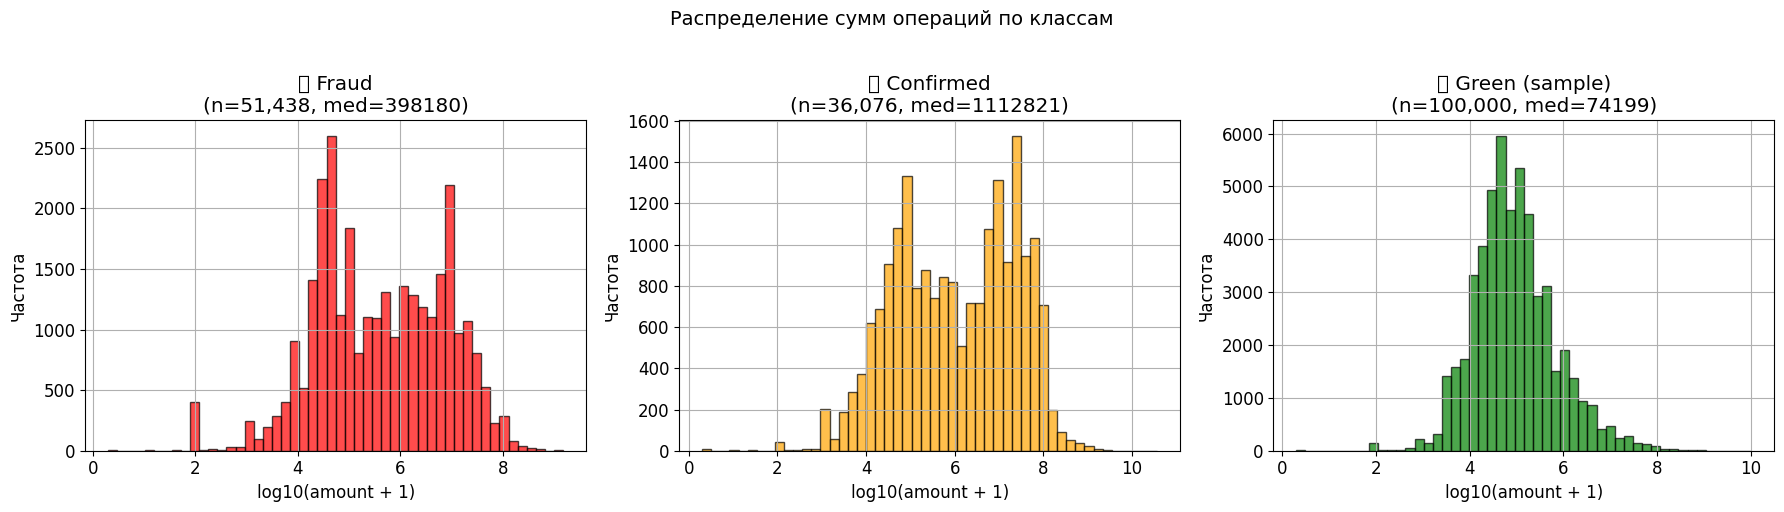


FRAUD ПО МЕСЯЦАМ (в train)
  2024-10: 6,252 fraud
  2024-11: 7,881 fraud
  2024-12: 7,023 fraud
  2025-01: 5,981 fraud
  2025-02: 4,987 fraud
  2025-03: 5,628 fraud
  2025-04: 6,689 fraud
  2025-05: 6,997 fraud


In [3]:
# === 1.2 Label Engineering ===

# Состав train assembled
train_with_labels = train_full.with_columns([
    pl.col('event_id').is_in(fraud_ids).alias('is_fraud'),
    pl.col('event_id').is_in(confirmed_ids).alias('is_confirmed'),
    pl.col('event_id').is_in(all_label_ids).alias('is_labeled'),
])

n_fraud_in_train = train_with_labels.filter(pl.col('is_fraud'))
n_confirmed_in_train = train_with_labels.filter(pl.col('is_confirmed'))
n_green_in_train = train_with_labels.filter(~pl.col('is_labeled'))

print("="*60)
print("СОСТАВ TRAIN ASSEMBLED (2.6M строк)")
print("="*60)
print(f"🔴 Fraud:     {len(n_fraud_in_train):>10,} ({100*len(n_fraud_in_train)/len(train_full):.2f}%)")
print(f"🟡 Confirmed: {len(n_confirmed_in_train):>10,} ({100*len(n_confirmed_in_train)/len(train_full):.2f}%)")
print(f"🟢 Green:     {len(n_green_in_train):>10,} ({100*len(n_green_in_train)/len(train_full):.2f}%)")
print(f"   ИТОГО:     {len(train_full):>10,}")
print(f"\n   Negatives = 🟡 + 🟢 = {len(n_confirmed_in_train)+len(n_green_in_train):,}")
print(f"   Ratio neg/pos = {(len(n_confirmed_in_train)+len(n_green_in_train))/len(n_fraud_in_train):.1f}:1")
print(f"   scale_pos_weight в LGBM = min(ratio, 50) = 50.0")

# Распределение сумм по классам
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, color, df) in zip(axes, [
    ('🔴 Fraud', 'red', n_fraud_in_train),
    ('🟡 Confirmed', 'orange', n_confirmed_in_train),
    ('🟢 Green (sample)', 'green', n_green_in_train.head(100000))  # сэмпл для скорости
]):
    amounts = df['operaton_amt'].drop_nulls().to_numpy()
    amounts = amounts[amounts > 0]
    ax.hist(np.log10(amounts + 1), bins=50, color=color, alpha=0.7, edgecolor='black')
    ax.set_title(f'{name}\n(n={len(df):,}, med={np.median(amounts):.0f})')
    ax.set_xlabel('log10(amount + 1)')
    ax.set_ylabel('Частота')

plt.suptitle('Распределение сумм операций по классам', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(str(ROOT / 'analytics' / 'label_amounts.png'), dpi=150, bbox_inches='tight')
plt.show()

# Распределение fraud по месяцам
print(f"\n{'='*60}")
print("FRAUD ПО МЕСЯЦАМ (в train)")
print(f"{'='*60}")
fraud_months = n_fraud_in_train.with_columns(
    pl.col('event_dttm').dt.strftime('%Y-%m').alias('month')
).group_by('month').len().sort('month')
for row in fraud_months.iter_rows():
    print(f"  {row[0]}: {row[1]:,} fraud")

---
## 1.3 Feature Importance (Топ-20 "двигателей")

Загружаем модель v14-C (рекорд LB=0.1010) и смотрим, какие фичи реально работают.

**Что проверяем:**
- Нет ли утечки (customer_id, event_id в топе)?
- Какие категории фичей доминируют (velocity, profiles, anomaly)?
- Совпадают ли importance между seed'ами?

FEATURE IMPORTANCE v14-C (gain, среднее по 5 seeds)
#    Feature                          Gain %    Cum %       CV
----------------------------------------------------------------------
1    anom_hourly_burst                 6.41%     6.4%    0.32
2    mcc_code                          3.52%     9.9%    0.13
3    prof_gap_std                      3.16%    13.1%    0.24
4    amt_ratio_7d_30d                  2.61%    15.7%    0.21
5    amt_sum_1h                        2.61%    18.3%    0.70
6    dormancy_days                     2.22%    20.5%    0.30
7    event_desc                        2.18%    22.7%    0.07
8    anom_daily_velocity               2.04%    24.7%    0.17
9    prof_hour_entropy                 1.92%    26.7%    0.32
10   prof_gap_mean                     1.90%    28.6%    0.16
11   prof_tx_per_day                   1.83%    30.4%    0.27
12   amt_sum_6h                        1.82%    32.2%    0.18
13   anom_amt_iqr_score                1.77%    34.0%    0.35
14   amt

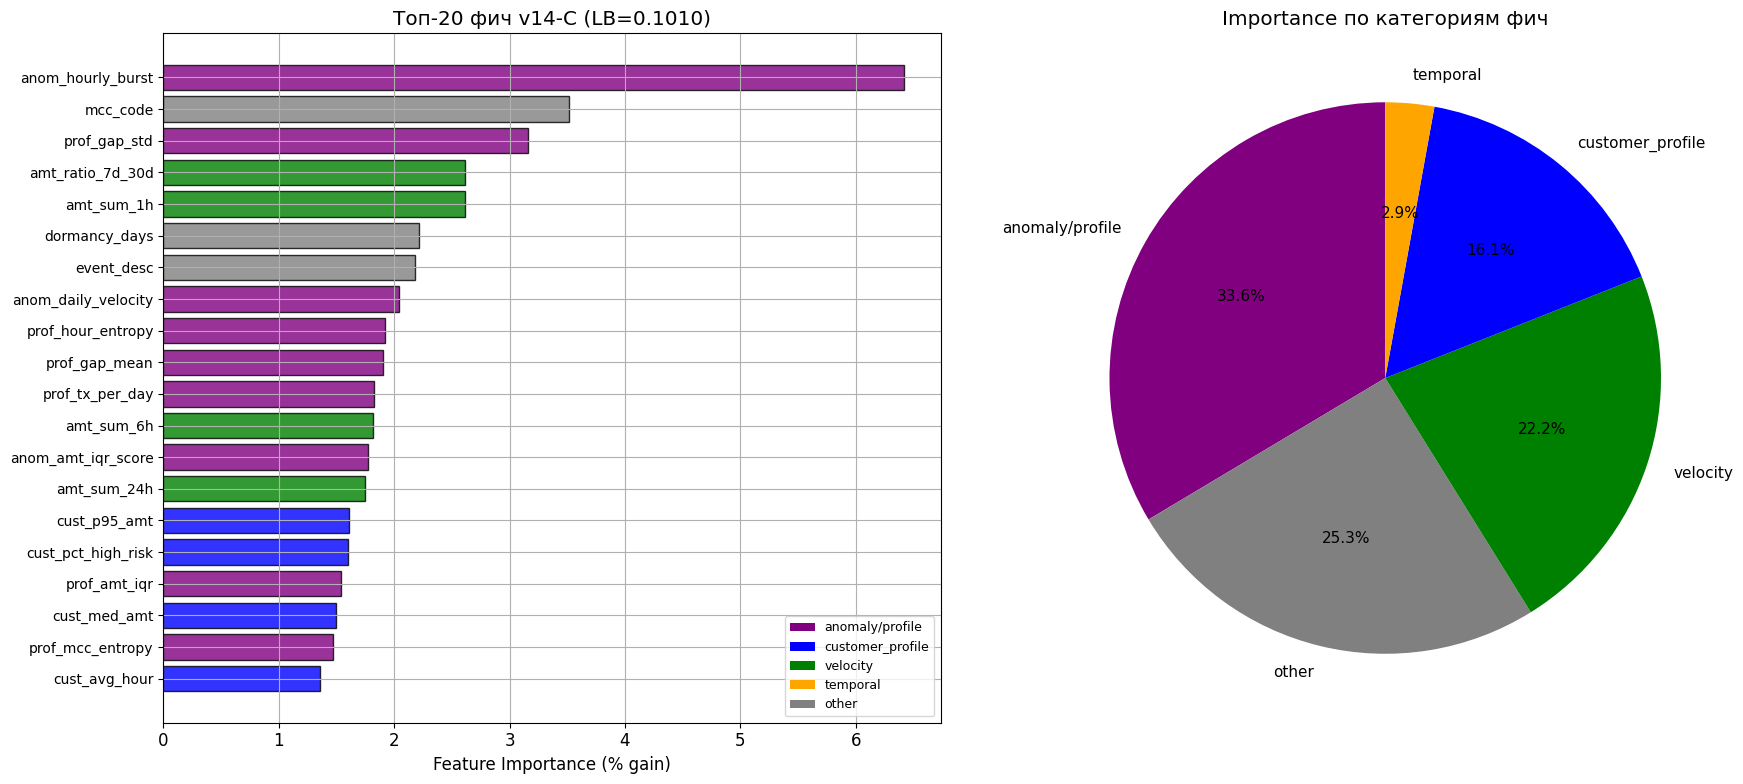

In [4]:
# === 1.3 Feature Importance v14-C ===
import importlib.util

spec9 = importlib.util.spec_from_file_location("v9", ROOT / "pipeline_v9.py")
v9 = importlib.util.module_from_spec(spec9)
spec9.loader.exec_module(v9)

spec14 = importlib.util.spec_from_file_location("v14", ROOT / "pipeline_v14.py")
v14 = importlib.util.module_from_spec(spec14)
spec14.loader.exec_module(v14)

base_feats = [c for c in v9.FEATURE_COLS if c in train_full.columns]
anom_feats = [c for c in v14.ANOMALY_FEATURES if c in train_full.columns]

# Загрузка всех 5 моделей v14-C
seeds = [42, 123, 777, 2024, 31337]
models_dir = ROOT / 'models_v14'
all_feats = base_feats + anom_feats

importances = {}
for seed in seeds:
    bst = lgb.Booster(model_file=str(models_dir / f'C_base_plus_anomaly_s{seed}.txt'))
    imp = bst.feature_importance(importance_type='gain')
    feat_names = bst.feature_name()
    importances[seed] = pd.Series(imp, index=feat_names)
    del bst

# Средний importance по seed'ам
imp_df = pd.DataFrame(importances)
imp_df['mean'] = imp_df.mean(axis=1)
imp_df['std'] = imp_df.std(axis=1)
imp_df['cv'] = imp_df['std'] / (imp_df['mean'] + 1e-10)
imp_df = imp_df.sort_values('mean', ascending=False)

# Нормализация в проценты
total_gain = imp_df['mean'].sum()
imp_df['pct'] = 100 * imp_df['mean'] / total_gain
imp_df['cum_pct'] = imp_df['pct'].cumsum()

# Топ-20
print("="*70)
print("FEATURE IMPORTANCE v14-C (gain, среднее по 5 seeds)")
print("="*70)
print(f"{'#':<4} {'Feature':<30} {'Gain %':>8} {'Cum %':>8} {'CV':>8}")
print("-"*70)
for i, (feat, row) in enumerate(imp_df.head(20).iterrows()):
    print(f"{i+1:<4} {feat:<30} {row['pct']:>7.2f}% {row['cum_pct']:>7.1f}% {row['cv']:>7.2f}")

print(f"\nВсего фич: {len(imp_df)}")
print(f"Топ-10 покрывают: {imp_df.head(10)['pct'].sum():.1f}%")
print(f"Топ-20 покрывают: {imp_df.head(20)['pct'].sum():.1f}%")
print(f"Нижние 50 покрывают: {imp_df.tail(50)['pct'].sum():.1f}%")

# Категоризация фич
categories = {}
for feat in imp_df.index:
    if feat.startswith('anom_') or feat.startswith('prof_'):
        categories[feat] = 'anomaly/profile'
    elif feat.startswith('cust_'):
        categories[feat] = 'customer_profile'
    elif any(x in feat for x in ['cnt_', 'amt_sum_', 'secs_since', 'ratio']):
        categories[feat] = 'velocity'
    elif feat in ['hour', 'weekday', 'month', 'is_night', 'day_of_month', 'hour_weekday']:
        categories[feat] = 'temporal'
    else:
        categories[feat] = 'other'

imp_df['category'] = [categories.get(f, 'other') for f in imp_df.index]

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Топ-20 feature importance
top20 = imp_df.head(20)
colors = {'anomaly/profile': 'purple', 'customer_profile': 'blue', 
           'velocity': 'green', 'temporal': 'orange', 'other': 'gray'}
bar_colors = [colors.get(top20.loc[f, 'category'], 'gray') for f in top20.index]

axes[0].barh(range(len(top20)), top20['pct'].values, color=bar_colors, edgecolor='black', alpha=0.8)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20.index, fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel('Feature Importance (% gain)')
axes[0].set_title('Топ-20 фич v14-C (LB=0.1010)')

# Легенда
from matplotlib.patches import Patch
legend_items = [Patch(facecolor=c, label=n) for n, c in colors.items()]
axes[0].legend(handles=legend_items, loc='lower right', fontsize=9)

# Importance по категориям
cat_imp = imp_df.groupby('category')['pct'].sum().sort_values(ascending=False)
axes[1].pie(cat_imp.values, labels=cat_imp.index, autopct='%1.1f%%',
            colors=[colors.get(c, 'gray') for c in cat_imp.index],
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Importance по категориям фич')

plt.tight_layout()
plt.savefig(str(ROOT / 'analytics' / 'feature_importance_v14c.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 1.4 Метрики: Local vs Лидерборд + PR-Curve

Сравнение локальных и LB результатов. Построение PR-кривой для v14-C.

СРАВНЕНИЕ LOCAL VAL vs LEADERBOARD
Модель                 Val PR-AUC    LB PR-AUC    Ratio    Delta
----------------------------------------------------------------------
v14-C (рекорд)             0.0440       0.1010     2.30    +0.0%
v16-IPW20                  0.0510       0.1009     1.98    -0.1%
v16-IPW50                  0.0510       0.0992     1.95    -1.8%
v15-B                      0.0450       0.0989     2.20    -2.1%
v14-D                      0.0550       0.0984     1.79    -2.6%
v16-IPW10                  0.0500       0.0981     1.96    -2.9%
v15-A                      0.0450       0.0981     2.18    -2.9%
v16-IPW100                 0.0520       0.0980     1.88    -3.0%
v10-M1                     0.0390       0.0973     2.49    -3.7%
v16-B (pretest)            0.0540       0.0965     1.79    -4.5%
v13-C                      0.0450       0.0951     2.11    -5.8%
v11                        0.0340       0.0754     2.22   -25.3%


[21:25:04 RAM:3.2GB]   Added 18 anomaly features: ['anom_amt_zscore', 'anom_amt_vs_median', 'anom_amt_vs_p95', 'anom_amt_vs_p99', 'anom_amt_above_max', 'anom_amt_iqr_score', 'anom_amt_below_min', 'anom_hour_zscore', 'anom_night_unusual', 'anom_weekend_unusual', 'anom_mcc_novel', 'anom_mcc_familiarity', 'anom_amt_vs_mcc_typical', 'anom_mcc_share', 'anom_gap_zscore', 'anom_gap_vs_median', 'anom_daily_velocity', 'anom_hourly_burst']



Фичи модели: 121, доступно: 121, отсутствует: 0


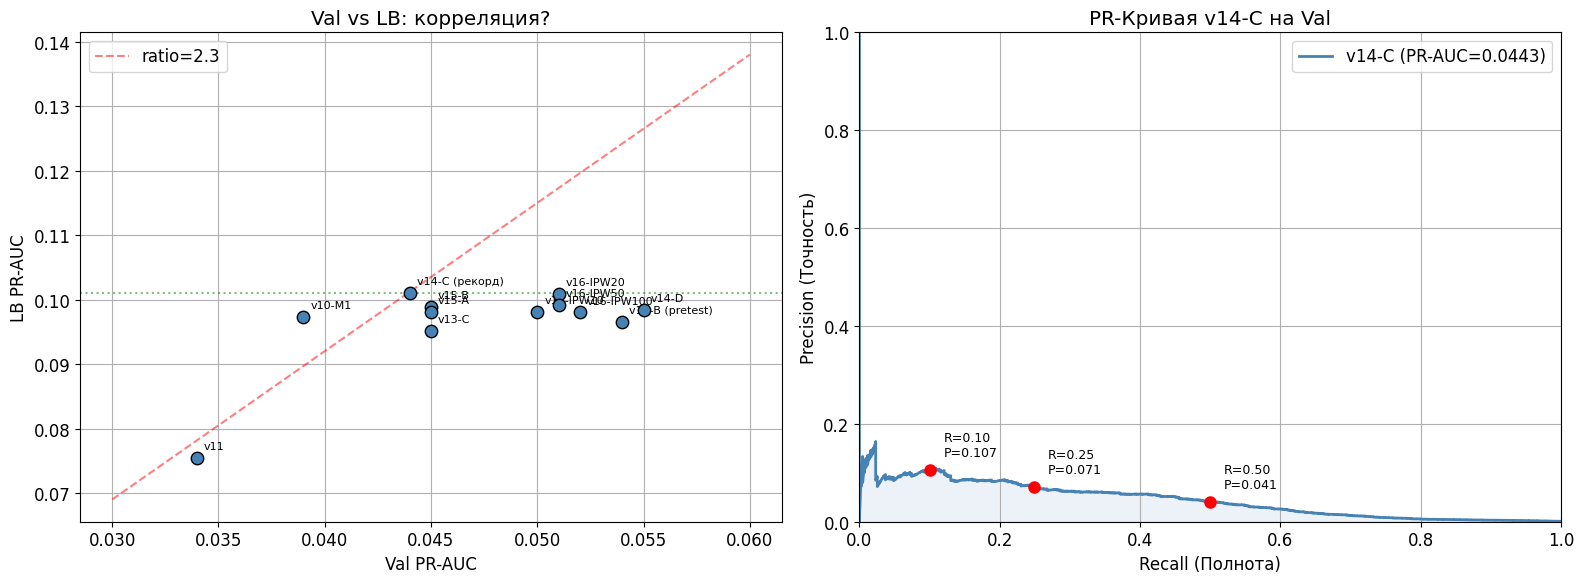


v14-C Val PR-AUC: 0.044314
Val fraud rate: 0.000822 (430 из 523280)


19880

In [5]:
# === 1.4 Метрики: Local vs LB + PR Curve ===

# Таблица Local vs LB
print("="*70)
print("СРАВНЕНИЕ LOCAL VAL vs LEADERBOARD")
print("="*70)
metrics = [
    ('v14-C (рекорд)', 0.044, 0.1010, '121 фич, anomaly, ES'),
    ('v16-IPW20', 0.051, 0.1009, '121 фич, IPW clip=20'),
    ('v16-IPW10', 0.050, 0.0981, '121 фич, IPW clip=10'),
    ('v16-IPW50', 0.051, 0.0992, '121 фич, IPW clip=50'),
    ('v16-IPW100', 0.052, 0.0980, '121 фич, IPW clip=100'),
    ('v16-B (pretest)', 0.054, 0.0965, '126 фич, pretest anom'),
    ('v15-B', 0.045, 0.0989, '139 фич, device+seq'),
    ('v15-A', 0.045, 0.0981, '121 фич, fixed 5K iter'),
    ('v14-D', 0.055, 0.0984, '121 фич, 20K trees'),
    ('v10-M1', 0.039, 0.0973, '91 фич, baseline'),
    ('v13-C', 0.045, 0.0951, '91 фич, 30K trees'),
    ('v11', 0.034, 0.0754, '129 фич, 3 models'),
]

print(f"{'Модель':<20} {'Val PR-AUC':>12} {'LB PR-AUC':>12} {'Ratio':>8} {'Delta':>8}")
print("-"*70)
for name, val, lb, desc in sorted(metrics, key=lambda x: -x[2]):
    ratio = lb / val if val > 0 else 0
    delta = 100 * (lb / 0.1010 - 1)
    print(f"{name:<20} {val:>12.4f} {lb:>12.4f} {ratio:>8.2f} {delta:>+7.1f}%")

# Scatter: val vs LB
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

vals = [m[1] for m in metrics]
lbs = [m[2] for m in metrics]
names_m = [m[0] for m in metrics]

axes[0].scatter(vals, lbs, s=80, c='steelblue', edgecolor='black', zorder=5)
for v, l, n in zip(vals, lbs, names_m):
    axes[0].annotate(n, (v, l), fontsize=8, ha='left', va='bottom', 
                     xytext=(5, 5), textcoords='offset points')
axes[0].plot([0.03, 0.06], [0.03*2.3, 0.06*2.3], 'r--', alpha=0.5, label='ratio=2.3')
axes[0].set_xlabel('Val PR-AUC')
axes[0].set_ylabel('LB PR-AUC')
axes[0].set_title('Val vs LB: корреляция?')
axes[0].legend()
axes[0].axhline(0.1010, color='green', linestyle=':', alpha=0.5, label='рекорд')

# PR Curve для v14-C на val
# Подготовка val с ПОЛНЫМИ фичами (как в пайплайне)
old_deep_profs = pl.read_parquet(FEATURES / 'deep_customer_profiles.parquet')
old_mcc_profs = pl.read_parquet(FEATURES / 'customer_mcc_profiles.parquet')
if old_mcc_profs['mcc_code'].dtype != pl.Int32:
    old_mcc_profs = old_mcc_profs.with_columns(pl.col('mcc_code').cast(pl.Int32))
old_profiles = pl.read_parquet(FEATURES / 'customer_profiles.parquet')

val_feats = v9.add_features(val_df)
val_feats = v9.add_customer_profiles(val_feats, old_profiles)
val_feats = v14.add_anomaly_features(val_feats, old_deep_profs, old_mcc_profs)

# Берём имена фич из модели
bst_tmp = lgb.Booster(model_file=str(models_dir / 'C_base_plus_anomaly_s42.txt'))
model_feats = bst_tmp.feature_name()
del bst_tmp

avail_feats = [c for c in model_feats if c in val_feats.columns]
missing = [c for c in model_feats if c not in val_feats.columns]
print(f"\nФичи модели: {len(model_feats)}, доступно: {len(avail_feats)}, отсутствует: {len(missing)}")
if missing:
    print(f"  Отсутствуют: {missing[:10]}...")
    # Заполняем отсутствующие нулями
    for c in missing:
        val_feats = val_feats.with_columns(pl.lit(0.0).alias(c))
    avail_feats = model_feats

X_val = val_feats.select(avail_feats).to_pandas().values.astype(np.float32)
y_val = val_feats.with_columns(
    pl.col('event_id').is_in(fraud_ids).cast(pl.Int8).alias('is_fraud')
)['is_fraud'].to_numpy()

# Предсказания v14-C (ансамбль 5 seeds)
preds_v14c = np.mean([
    lgb.Booster(model_file=str(models_dir / f'C_base_plus_anomaly_s{s}.txt')).predict(X_val)
    for s in seeds], axis=0)

prauc = average_precision_score(y_val, preds_v14c)
precision, recall, thresholds = precision_recall_curve(y_val, preds_v14c)

axes[1].plot(recall, precision, color='steelblue', linewidth=2, label=f'v14-C (PR-AUC={prauc:.4f})')
axes[1].fill_between(recall, precision, alpha=0.1, color='steelblue')
axes[1].set_xlabel('Recall (Полнота)')
axes[1].set_ylabel('Precision (Точность)')
axes[1].set_title('PR-Кривая v14-C на Val')
axes[1].legend(fontsize=12)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

# Аннотация ключевых точек
for target_recall in [0.1, 0.25, 0.5]:
    idx = np.argmin(np.abs(recall - target_recall))
    axes[1].plot(recall[idx], precision[idx], 'ro', markersize=8)
    axes[1].annotate(f'R={recall[idx]:.2f}\nP={precision[idx]:.3f}', 
                     (recall[idx], precision[idx]), fontsize=9,
                     xytext=(10, 10), textcoords='offset points')

plt.tight_layout()
plt.savefig(str(ROOT / 'analytics' / 'metrics_val_vs_lb.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nv14-C Val PR-AUC: {prauc:.6f}")
print(f"Val fraud rate: {y_val.mean():.6f} ({y_val.sum()} из {len(y_val)})")

del old_deep_profs, old_mcc_profs, old_profiles, val_feats; gc.collect()

---
## 1.5 Target Distribution по времени

Есть ли аномальные всплески fraud по месяцам/неделям? Если модель "выучила" что фрод бывает в определённые месяцы — это утечка.

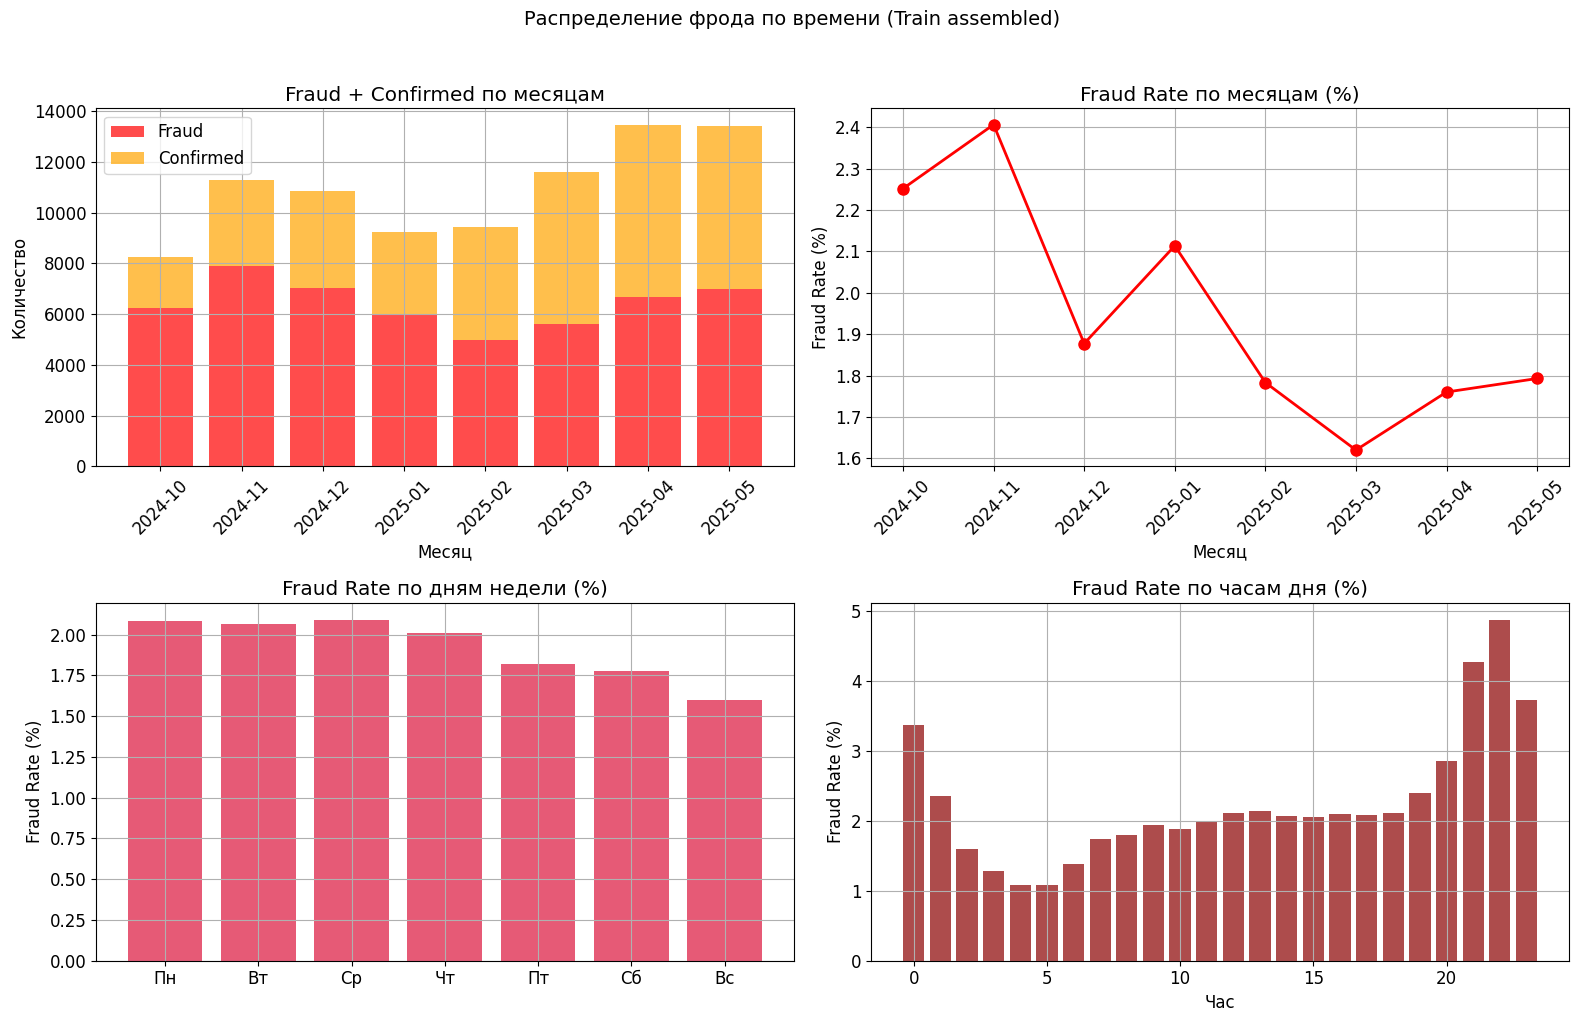

DISTRIBUTION SHIFT: TRAIN vs TEST
Test по месяцам:
  2025-06: 268,999
  2025-07: 276,780
  2025-08: 87,904

Train: Oct'24 — May'25
Test:  Jun'25 — Aug'25
→ НУЛЕВОЕ пересечение по времени!


7038

In [6]:
# === 1.5 Target Distribution по времени ===

# Используем train_full (который уже имеет target) 
train_temporal = train_full.with_columns([
    pl.col('event_id').is_in(fraud_ids).cast(pl.Int8).alias('is_fraud'),
    pl.col('event_id').is_in(confirmed_ids).cast(pl.Int8).alias('is_confirmed'),
    pl.col('event_dttm').dt.strftime('%Y-%m').alias('ym'),
    pl.col('event_dttm').dt.weekday().alias('dow'),
    pl.col('event_dttm').dt.hour().alias('hr'),
])

# По месяцам
monthly = train_temporal.group_by('ym').agg([
    pl.col('is_fraud').sum().alias('n_fraud'),
    pl.col('is_confirmed').sum().alias('n_confirmed'),
    pl.len().alias('n_total'),
]).sort('ym').to_pandas()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Fraud count по месяцам
axes[0,0].bar(monthly['ym'], monthly['n_fraud'], color='red', alpha=0.7, label='Fraud')
axes[0,0].bar(monthly['ym'], monthly['n_confirmed'], bottom=monthly['n_fraud'], 
              color='orange', alpha=0.7, label='Confirmed')
axes[0,0].set_title('Fraud + Confirmed по месяцам')
axes[0,0].set_xlabel('Месяц')
axes[0,0].set_ylabel('Количество')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=45)

# Fraud RATE по месяцам
monthly['fraud_rate'] = monthly['n_fraud'] / monthly['n_total'] * 100
axes[0,1].plot(monthly['ym'], monthly['fraud_rate'], 'ro-', linewidth=2, markersize=8)
axes[0,1].set_title('Fraud Rate по месяцам (%)')
axes[0,1].set_xlabel('Месяц')
axes[0,1].set_ylabel('Fraud Rate (%)')
axes[0,1].tick_params(axis='x', rotation=45)

# По дню недели
dow_stats = train_temporal.group_by('dow').agg([
    pl.col('is_fraud').sum().alias('n_fraud'),
    pl.len().alias('n_total'),
]).sort('dow').to_pandas()
dow_stats['fraud_rate'] = dow_stats['n_fraud'] / dow_stats['n_total'] * 100
dow_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
axes[1,0].bar(dow_names, dow_stats['fraud_rate'], color='crimson', alpha=0.7)
axes[1,0].set_title('Fraud Rate по дням недели (%)')
axes[1,0].set_ylabel('Fraud Rate (%)')

# По часу дня
hour_stats = train_temporal.group_by('hr').agg([
    pl.col('is_fraud').sum().alias('n_fraud'),
    pl.len().alias('n_total'),
]).sort('hr').to_pandas()
hour_stats['fraud_rate'] = hour_stats['n_fraud'] / hour_stats['n_total'] * 100
axes[1,1].bar(hour_stats['hr'], hour_stats['fraud_rate'], color='darkred', alpha=0.7)
axes[1,1].set_title('Fraud Rate по часам дня (%)')
axes[1,1].set_xlabel('Час')
axes[1,1].set_ylabel('Fraud Rate (%)')

plt.suptitle('Распределение фрода по времени (Train assembled)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(str(ROOT / 'analytics' / 'fraud_temporal.png'), dpi=150, bbox_inches='tight')
plt.show()

# Distribution shift: train vs test
print("="*60)
print("DISTRIBUTION SHIFT: TRAIN vs TEST")
print("="*60)
test_months = test_df.with_columns(
    pl.col('event_dttm').dt.strftime('%Y-%m').alias('ym')
).group_by('ym').len().sort('ym')
print("Test по месяцам:")
for row in test_months.iter_rows():
    print(f"  {row[0]}: {row[1]:,}")
print(f"\nTrain: Oct'24 — May'25")
print(f"Test:  Jun'25 — Aug'25")
print(f"→ НУЛЕВОЕ пересечение по времени!")

del train_temporal; gc.collect()